In [3]:
import numpy as np
import pandas as pd

In [4]:
df=pd.read_csv('data/tested.csv',usecols=['Age','Survived','Fare'])

In [5]:
df.isnull().sum()

Survived     0
Age         86
Fare         1
dtype: int64

In [6]:
df['Age'].fillna(df['Age'].mean(),inplace=True)
df['Fare'].fillna(df['Fare'].mean(),inplace=True)

C:\Users\Sulav Dhami\AppData\Local\Temp\ipykernel_19360\4195263108.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)
C:\Users\Sulav Dhami\AppData\Local\Temp\ipykernel_19360\4195263108.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

In [7]:
df

,Survived,Age,Fare
0,0,34.50000,7.8292
1,1,47.00000,7.0000
2,0,62.00000,9.6875
3,0,27.00000,8.6625
4,1,22.00000,12.2875
...,...,...,...
413,0,30.27259,8.0500
414,1,39.00000,108.9000
415,0,38.50000,7.2500
416,0,30.27259,8.0500


In [8]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [9]:
from sklearn.model_selection import train_test_split
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
xTrain.shape

(334, 2)

In [11]:
xTest.shape

(84, 2)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

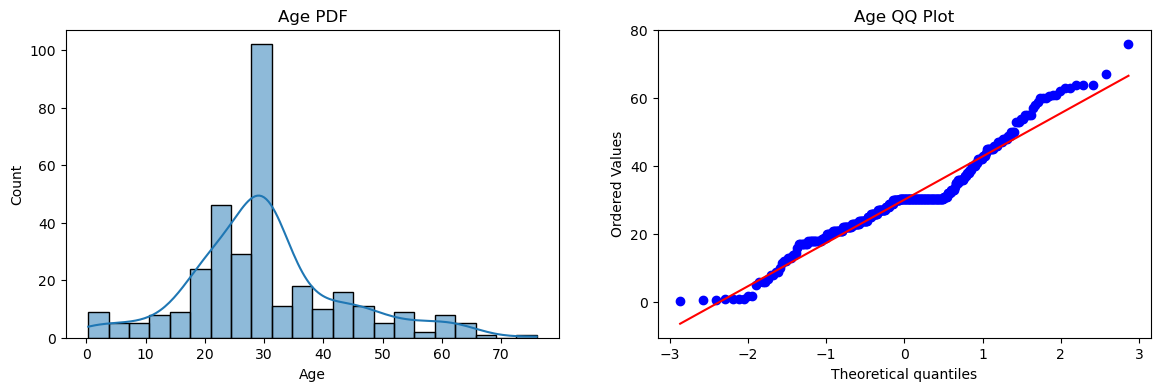

In [13]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(xTrain['Age'],kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(xTrain['Age'],dist='norm',plot=plt)
plt.title('Age QQ Plot')
plt.show()

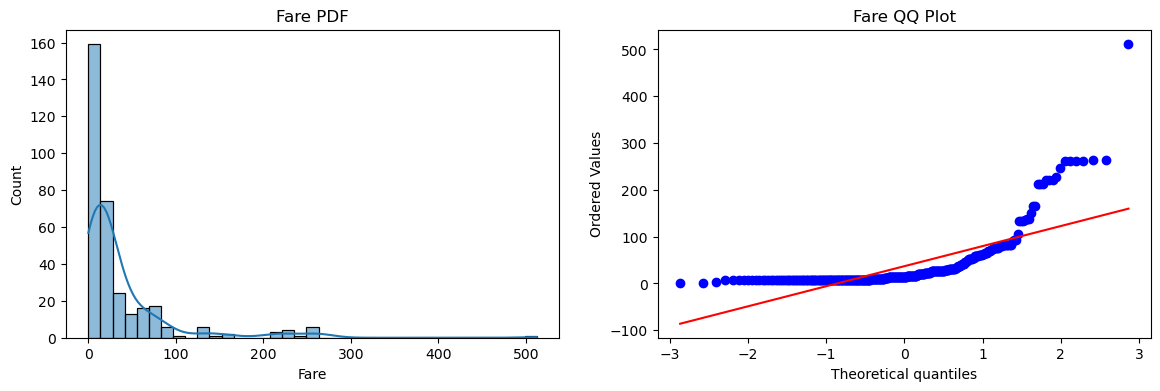

In [14]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(xTrain['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(xTrain['Fare'],dist='norm',plot=plt.gca())
plt.title('Fare QQ Plot')
plt.show()

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

In [16]:
clf1.fit(xTrain,yTrain)
clf2.fit(xTrain,yTrain)

a=clf1.predict(xTest)
b=clf2.predict(xTest)


In [17]:
from sklearn.metrics import accuracy_score
print("With Logistic Regression:",accuracy_score(yTest,a))
print("With Tree Classifier:",accuracy_score(yTest,b))

With Logistic Regression: 0.6071428571428571
With Tree Classifier: 0.5357142857142857


In [18]:
from sklearn.preprocessing import FunctionTransformer
ft=FunctionTransformer(func=np.log1p)

In [19]:
xTrainTransformed=ft.fit_transform(xTrain)
xTestTransformed=ft.transform(xTest)

In [20]:
clf3=LogisticRegression()
clf4=DecisionTreeClassifier()

clf3.fit(xTrainTransformed,yTrain)
clf4.fit(xTrainTransformed,yTrain)

yPred=clf3.predict(xTestTransformed)
yPred1=clf4.predict(xTestTransformed)

In [21]:
print("With Logistic Regression:",accuracy_score(yTest,yPred))
print("With Tree Classifier:",accuracy_score(yTest,yPred1))

With Logistic Regression: 0.6190476190476191
With Tree Classifier: 0.5476190476190477


In [22]:
from sklearn.model_selection import cross_val_score
xTransformed=ft.fit_transform(x)

In [23]:
clf5=LogisticRegression()
clf6=DecisionTreeClassifier()

In [24]:
print("LR",np.mean(cross_val_score(clf5,xTransformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf6,xTransformed,y,scoring='accuracy',cv=10)))

LR 0.6556329849012775
DT 0.5885598141695703


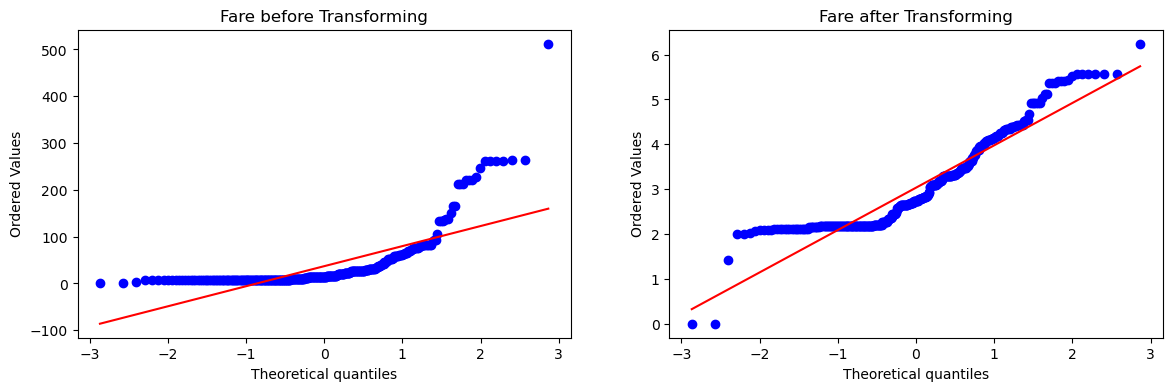

In [25]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(xTrain['Fare'],dist='norm',plot=plt)
plt.title("Fare before Transforming")

plt.subplot(122)
stats.probplot(xTrainTransformed['Fare'],dist='norm',plot=plt)
plt.title("Fare after Transforming")

plt.show()

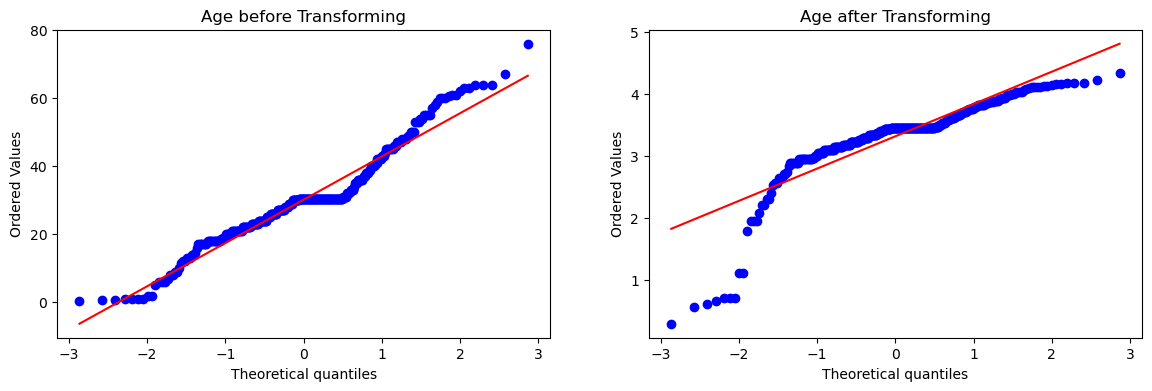

In [26]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(xTrain['Age'],dist='norm',plot=plt)
plt.title("Age before Transforming")

plt.subplot(122)
stats.probplot(xTrainTransformed['Age'],dist='norm',plot=plt)
plt.title("Age after Transforming")

plt.show()

In [27]:
from sklearn.compose import ColumnTransformer
ct=ColumnTransformer([
    ('Fare',FunctionTransformer(func=np.log1p),['Fare'])
],remainder='passthrough')

xTrainTransformed2=ct.fit_transform(xTrain)
xTestTransformed2=ct.transform(xTest)

In [28]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(xTrainTransformed2,yTrain)
clf2.fit(xTrainTransformed2,yTrain)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
ypred1=clf.predict(xTestTransformed2)
ypred2=clf2.predict(xTestTransformed2)

In [30]:
print('LR',accuracy_score(yTest,ypred1))
print('DT',accuracy_score(yTest,ypred2))

LR 0.6190476190476191
DT 0.5357142857142857


In [31]:
xTransformed2=ct.fit_transform(x)

clf3=LogisticRegression()
clf4=DecisionTreeClassifier()

In [32]:
print("LR",np.mean(cross_val_score(clf3,xTransformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf4,xTransformed2,y,scoring='accuracy',cv=10)))

LR 0.6507549361207897
DT 0.5789779326364691


In [33]:
def apply_transform(function):
  x=df.iloc[:,1:]
  y=df.iloc[:,0]

  ct1=ColumnTransformer([
      ('custom',FunctionTransformer(function),['Fare'])
  ],remainder='passthrough')

  xTrans=ct1.fit_transform(x)

  clf=LogisticRegression()

  print('LR',np.mean(cross_val_score(clf,xTrans,y,scoring='accuracy',cv=10)))

  plt.figure(figsize=(14,4))

  plt.subplot(121)
  stats.probplot(x['Fare'],dist='norm',plot=plt)
  plt.title('Fare before Transformation')

  plt.subplot(122)
  stats.probplot(xTrans[:,0],dist='norm',plot=plt)
  plt.title('Fare after Transformation')

  plt.show()


LR 0.6363530778164923


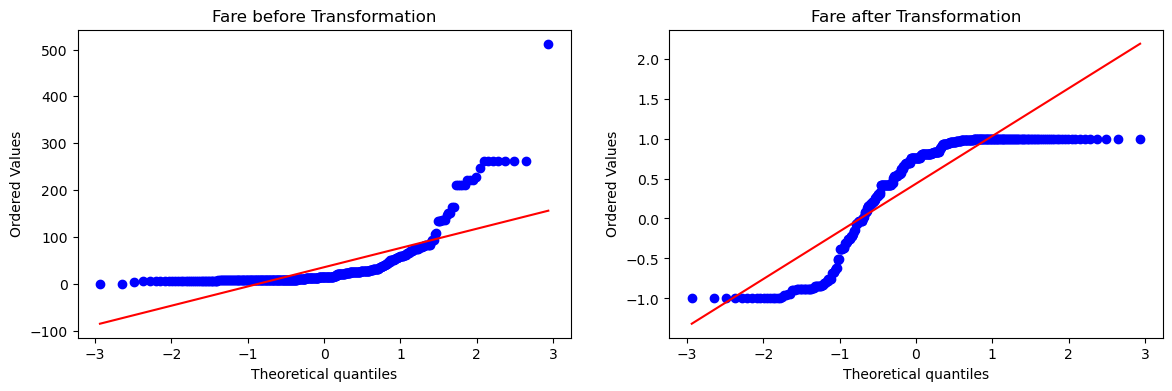

In [34]:
apply_transform(np.sin)
# apply_transform(lambda x: 1/(x+0.1))